# Localização Capacitada de Instalações com Sustentabilidade e Resiliência

**Disciplina:** Modelos e Algoritmos de Otimização
**Professor:** Sérgio Queiroz
**Integrantes:** Cláudio Meireles · Felipe Dutra · Lucas Fiche · Pedro Araújo
**Solver:** Gurobi (gurobipy)

Este notebook contém a implementação completa do projeto: o modelo original
(Capacitated Facility Location Problem - CFLP) inspirado nos exemplos do
[Gurobi modeling-examples](https://github.com/Gurobi/modeling-examples), e
um modelo estendido com três novas restrições:

1. **(E1) Restrição de CO₂:** orçamento máximo de emissões de transporte;
2. **(E2) Resiliência (multi-sourcing):** cada cliente atendido por ≥ 2 CDs;
3. **(E3) SLA de distância:** não atender clientes além de `D_MAX` km.

Os dados são lidos a partir de arquivos CSV (`facilities.csv` e `customers.csv`).

---

## 1. Setup

Instalação do `gurobipy` no Colab e leitura dos dados do projeto.

In [1]:
# !pip install gurobipy --quiet
import gurobipy as gp
from gurobipy import GRB
print("Gurobi:", gp.gurobi.version())

Gurobi: (13, 0, 2)


In [2]:
import math, csv, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Caminho dos dados (no Colab, faça upload ou clone do repositório).
DATA = Path("../data")
if not DATA.exists():
    DATA = Path("data")  # fallback

## 2. Leitura dos dados

Os arquivos CSV foram gerados a partir de uma instância realista com 12 candidatos
a centro de distribuição (capitais brasileiras) e 60 clientes (cidades-demanda).

In [3]:
facs = pd.read_csv(DATA / "facilities.csv")
cus  = pd.read_csv(DATA / "customers.csv")
print("Instalações candidatas:", len(facs))
print("Clientes              :", len(cus))
print("Demanda total         :", cus["demanda"].sum(), "ton/mês")
print("Capacidade total      :", facs["capacidade"].sum(), "ton/mês")
facs.head()

Instalações candidatas: 12
Clientes              : 60
Demanda total         : 2640 ton/mês
Capacidade total      : 6700 ton/mês


,id,nome,lat,lon,custo_fixo,capacidade
0,0,Sao Paulo-SP,-23.5505,-46.6333,450000,900
1,1,Rio de Janeiro-RJ,-22.9068,-43.1729,380000,700
2,2,Belo Horizonte-MG,-19.9167,-43.9345,300000,650
3,3,Curitiba-PR,-25.4284,-49.2733,280000,600
4,4,Porto Alegre-RS,-30.0346,-51.2177,290000,550


In [4]:
cus.head()

,id,nome,lat,lon,demanda
0,0,Sao Paulo,-23.5505,-46.6333,54
1,1,Rio de Janeiro,-22.9068,-43.1729,43
2,2,Belo Horizonte,-19.9167,-43.9345,75
3,3,Curitiba,-25.4284,-49.2733,71
4,4,Porto Alegre,-30.0346,-51.2177,68


### Visualização geográfica

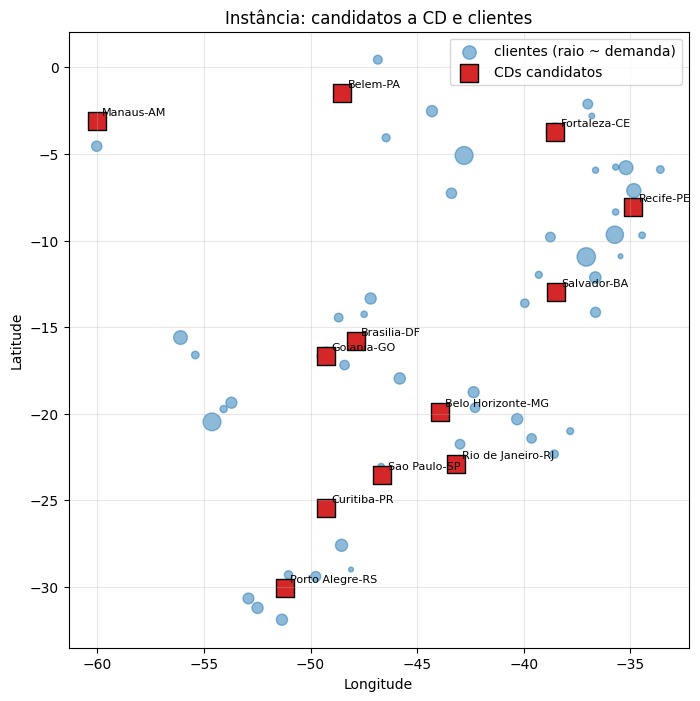

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(cus["lon"], cus["lat"], s=cus["demanda"]*1.5, c="tab:blue",
           alpha=0.5, label="clientes (raio ~ demanda)")
ax.scatter(facs["lon"], facs["lat"], s=180, c="tab:red", marker="s",
           edgecolors="black", label="CDs candidatos")
for _, r in facs.iterrows():
    ax.annotate(r["nome"], (r["lon"], r["lat"]), fontsize=8, xytext=(4,4),
                textcoords="offset points")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Instância: candidatos a CD e clientes")
ax.legend(); ax.grid(alpha=.3)
plt.show()

## 3. Matriz de distâncias (Haversine)

In [6]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2-lat1); dlam = math.radians(lon2-lon1)
    a = math.sin(dphi/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dlam/2)**2
    return 2*R*math.asin(math.sqrt(a))

dist = {(int(fi.id), int(cj.id)): haversine_km(fi.lat, fi.lon, cj.lat, cj.lon)
        for fi in facs.itertuples() for cj in cus.itertuples()}
print("Pares (i,j):", len(dist), " | dist média:",
      f"{np.mean(list(dist.values())):.1f} km")

Pares (i,j): 720  | dist média: 1537.7 km


## 4. Modelo ORIGINAL (CFLP clássico)

$$\begin{aligned}
\min \quad & \sum_i f_i\, y_i \;+\; \sum_i\sum_j c_{ij}\, d_j\, x_{ij} \\
\text{s.a.}\quad & \sum_i x_{ij} = 1, \qquad \forall j \\
& \sum_j d_j\, x_{ij} \le s_i\, y_i, \qquad \forall i \\
& y_i \in \{0,1\},\quad x_{ij} \ge 0
\end{aligned}$$

In [7]:
COST_PER_TON_KM = 0.50  # R$ por ton-km

def solve_original(verbose=True):
    F = facs["id"].tolist(); C = cus["id"].tolist()
    f_cost = dict(zip(facs["id"], facs["custo_fixo"]))
    s_cap  = dict(zip(facs["id"], facs["capacidade"]))
    d      = dict(zip(cus["id"], cus["demanda"]))

    m = gp.Model("CFLP_original")
    if not verbose: m.Params.OutputFlag = 0
    y = m.addVars(F, vtype=GRB.BINARY, name="y")
    x = m.addVars(F, C, lb=0, ub=1, name="x")

    m.setObjective(
        gp.quicksum(f_cost[i]*y[i] for i in F)
        + gp.quicksum(COST_PER_TON_KM*dist[(i,j)]*d[j]*x[i,j] for i in F for j in C),
        GRB.MINIMIZE)
    m.addConstrs((gp.quicksum(x[i,j] for i in F) == 1 for j in C), "atend")
    m.addConstrs((gp.quicksum(d[j]*x[i,j] for j in C) <= s_cap[i]*y[i] for i in F), "cap")

    t0 = time.time(); m.optimize(); dt = time.time() - t0
    return m, y, x, dt

m_o, y_o, x_o, dt_o = solve_original(verbose=False)
print(f"Status   : {m_o.status} | Tempo: {dt_o:.3f}s")
print(f"Obj      : R$ {m_o.objVal:,.2f}")
abertos_o = [int(i) for i in facs.id if y_o[i].X > 0.5]
print("Abertos  :", [facs.loc[facs.id==i, 'nome'].values[0] for i in abertos_o])

Restricted license - for non-production use only - expires 2027-11-29


Status   : 2 | Tempo: 0.113s
Obj      : R$ 2,037,870.34
Abertos  : ['Belo Horizonte-MG', 'Curitiba-PR', 'Salvador-BA', 'Recife-PE', 'Belem-PA']


## 5. Modelo ESTENDIDO

Acrescentamos as variáveis $z_{ij}\in\{0,1\}$ (sinaliza se $i$ atende $j$) e três
famílias de restrições:

**(E1) Orçamento de CO₂**
$$\sum_i\sum_j \mathrm{ef}\,\cdot\,\mathrm{dist}_{ij}\,\cdot\,d_j\,\cdot\,x_{ij} \le E_{\max}$$

**(E2) Resiliência (≥ K fontes por cliente)**
$$x_{ij} \le z_{ij},\quad z_{ij}\le y_i,\quad \sum_i z_{ij} \ge K_{\min},\quad x_{ij}\le \mathrm{MaxShare}$$

**(E3) SLA de distância**
$$x_{ij}=0\quad \text{se}\quad \mathrm{dist}_{ij} > D_{\max}$$

In [8]:
# Parâmetros das extensões
EF        = 0.062     # kg CO2 por ton-km (frete rodoviário)
E_MAX     = 60_000.0  # kg CO2 / mês (~72% do nível do ótimo original)
K_MIN     = 2         # multi-sourcing mínimo
MAX_SHARE = 0.70      # nenhum CD cobre > 70% de um cliente
D_MAX     = 2200.0    # SLA: distância máxima de atendimento (km)

def solve_extended(e_max=E_MAX, k_min=K_MIN, max_share=MAX_SHARE, d_max=D_MAX,
                   verbose=False):
    F = facs["id"].tolist(); C = cus["id"].tolist()
    f_cost = dict(zip(facs["id"], facs["custo_fixo"]))
    s_cap  = dict(zip(facs["id"], facs["capacidade"]))
    d      = dict(zip(cus["id"], cus["demanda"]))

    m = gp.Model("CFLP_extendido")
    if not verbose: m.Params.OutputFlag = 0
    y = m.addVars(F, vtype=GRB.BINARY, name="y")
    x = m.addVars(F, C, lb=0, ub=max_share, name="x")
    z = m.addVars(F, C, vtype=GRB.BINARY, name="z")

    m.setObjective(
        gp.quicksum(f_cost[i]*y[i] for i in F)
        + gp.quicksum(COST_PER_TON_KM*dist[(i,j)]*d[j]*x[i,j] for i in F for j in C),
        GRB.MINIMIZE)
    m.addConstrs((gp.quicksum(x[i,j] for i in F) == 1 for j in C), "atend")
    m.addConstrs((gp.quicksum(d[j]*x[i,j] for j in C) <= s_cap[i]*y[i] for i in F), "cap")

    # (E1) CO2
    m.addConstr(gp.quicksum(EF*dist[(i,j)]*d[j]*x[i,j] for i in F for j in C) <= e_max,
                "co2_budget")
    # (E2) resiliência
    m.addConstrs((x[i,j] <= z[i,j] for i in F for j in C), "link_xz")
    m.addConstrs((z[i,j] <= y[i] for i in F for j in C), "z_le_y")
    m.addConstrs((gp.quicksum(z[i,j] for i in F) >= k_min for j in C), "multi_src")
    # (E3) distância máxima
    blocked = 0
    for i in F:
        for j in C:
            if dist[(i,j)] > d_max:
                x[i,j].UB = 0.0; z[i,j].UB = 0.0; blocked += 1

    t0 = time.time(); m.optimize(); dt = time.time() - t0
    return m, y, x, z, dt, blocked

m_e, y_e, x_e, z_e, dt_e, bloq = solve_extended(verbose=False)
print(f"Status   : {m_e.status} | Tempo: {dt_e:.3f}s | Pares bloqueados: {bloq}")
print(f"Obj      : R$ {m_e.objVal:,.2f}")
abertos_e = [int(i) for i in facs.id if y_e[i].X > 0.5]
print("Abertos  :", [facs.loc[facs.id==i,'nome'].values[0] for i in abertos_e])

Status   : 2 | Tempo: 0.076s | Pares bloqueados: 169
Obj      : R$ 3,252,748.85
Abertos  : ['Belo Horizonte-MG', 'Curitiba-PR', 'Porto Alegre-RS', 'Salvador-BA', 'Recife-PE', 'Fortaleza-CE', 'Brasilia-DF', 'Goiania-GO', 'Manaus-AM', 'Belem-PA']


## 6. Comparação Original vs Estendido

In [9]:
def kpis(m, y, x):
    transp = sum(COST_PER_TON_KM*dist[(int(fi.id),int(cj.id))]*cj.demanda*x[int(fi.id),int(cj.id)].X
                 for fi in facs.itertuples() for cj in cus.itertuples())
    fixo  = sum(fi.custo_fixo*y[int(fi.id)].X for fi in facs.itertuples())
    co2   = sum(EF*dist[(int(fi.id),int(cj.id))]*cj.demanda*x[int(fi.id),int(cj.id)].X
                for fi in facs.itertuples() for cj in cus.itertuples())
    abertos = int(sum(1 for fi in facs.itertuples() if y[int(fi.id)].X>0.5))
    return dict(obj=m.objVal, fixo=fixo, transp=transp, co2=co2, abertos=abertos,
                vars=m.NumVars, constrs=m.NumConstrs)

ko = kpis(m_o, y_o, x_o); ke = kpis(m_e, y_e, x_e)
df = pd.DataFrame({"original": ko, "estendido": ke})
df.loc["delta_%"] = 100*(df.loc[["obj","fixo","transp","co2","abertos"]]["estendido"] /
                          df.loc[["obj","fixo","transp","co2","abertos"]]["original"] - 1)
df

,original,estendido
obj,2.037870e+06,3.252749e+06
fixo,1.370000e+06,2.780000e+06
transp,6.678703e+05,4.727489e+05
co2,8.281592e+04,5.862086e+04
abertos,5.000000e+00,1.000000e+01
vars,7.320000e+02,1.452000e+03
constrs,7.200000e+01,1.573000e+03
delta_%,NaN,NaN


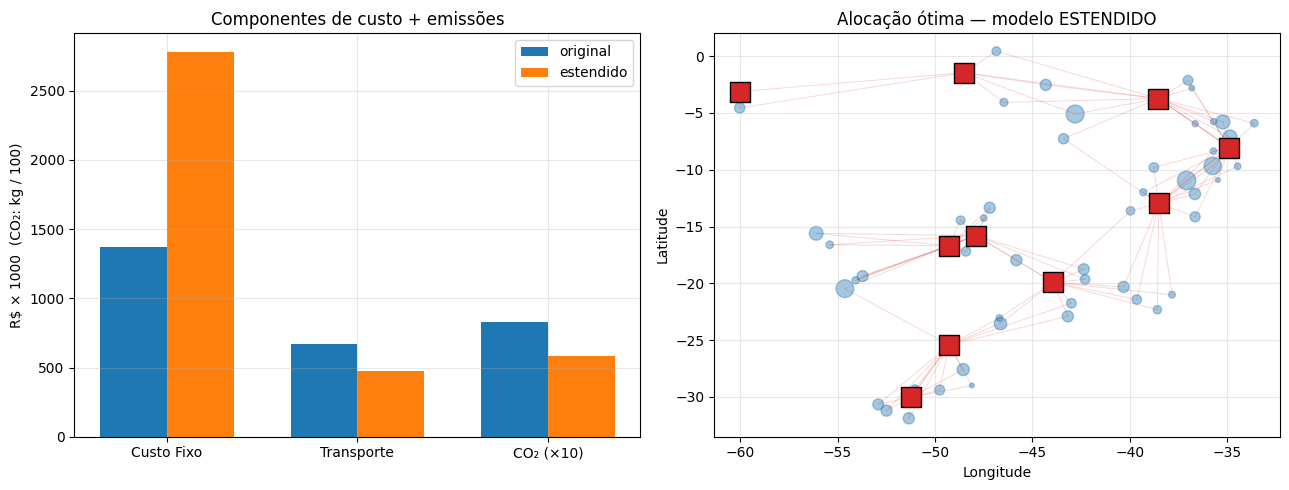

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
labels = ["Custo Fixo", "Transporte", "CO₂ (×10)"]
orig_v = [ko["fixo"]/1e3, ko["transp"]/1e3, ko["co2"]/1e2]
ext_v  = [ke["fixo"]/1e3, ke["transp"]/1e3, ke["co2"]/1e2]
xpos = np.arange(len(labels)); w = 0.35
axes[0].bar(xpos-w/2, orig_v, w, label="original")
axes[0].bar(xpos+w/2, ext_v,  w, label="estendido")
axes[0].set_xticks(xpos); axes[0].set_xticklabels(labels)
axes[0].set_ylabel("R$ × 1000  (CO₂: kg / 100)")
axes[0].set_title("Componentes de custo + emissões")
axes[0].legend(); axes[0].grid(alpha=.3)

# mapa de alocação do modelo estendido
ax = axes[1]
ax.scatter(cus["lon"], cus["lat"], s=cus["demanda"]*1.5, c="tab:blue", alpha=.4)
for fi in facs.itertuples():
    if y_e[int(fi.id)].X > 0.5:
        ax.scatter(fi.lon, fi.lat, s=220, c="tab:red", marker="s",
                   edgecolors="black", zorder=5)
        for cj in cus.itertuples():
            if x_e[int(fi.id), int(cj.id)].X > 1e-6:
                ax.plot([fi.lon, cj.lon], [fi.lat, cj.lat],
                        c="tab:red", alpha=0.18, lw=.7)
ax.set_title("Alocação ótima — modelo ESTENDIDO")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 7. Análise de sensibilidade: curva de Pareto custo × CO₂

Variamos o orçamento de CO₂ e observamos como o custo ótimo se comporta.
Permite quantificar o **custo marginal da redução de emissões**.

In [11]:
base_co2 = ko["co2"]
fracs = [0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 1.00, 1.10]
rows = []
for fr in fracs:
    bud = base_co2 * fr
    me, ye, xe, ze, dt, _ = solve_extended(e_max=bud, verbose=False)
    if me.status == GRB.OPTIMAL:
        co2_real = sum(EF*dist[(int(fi.id),int(cj.id))]*cj.demanda*xe[int(fi.id),int(cj.id)].X
                       for fi in facs.itertuples() for cj in cus.itertuples())
        rows.append((fr, bud, me.objVal, co2_real,
                     int(sum(1 for fi in facs.itertuples() if ye[int(fi.id)].X>0.5))))
    else:
        rows.append((fr, bud, None, None, None))

pareto = pd.DataFrame(rows, columns=["frac","co2_budget","custo","co2_efetivo","n_CDs"])
pareto

,frac,co2_budget,custo,co2_efetivo,n_CDs
0,0.65,53830.349497,NaN,NaN,NaN
1,0.70,57971.145613,3.604994e+06,55179.301955,11.0
2,0.75,62111.941728,3.252749e+06,58620.857526,10.0
3,0.80,66252.737843,2.976372e+06,62790.179436,9.0
4,0.85,70393.533958,2.750112e+06,69453.845952,8.0
5,0.90,74534.330073,2.715458e+06,71356.777168,8.0
6,1.00,82815.922304,2.507420e+06,81520.076612,7.0
7,1.10,91097.514534,2.316770e+06,90119.450633,6.0


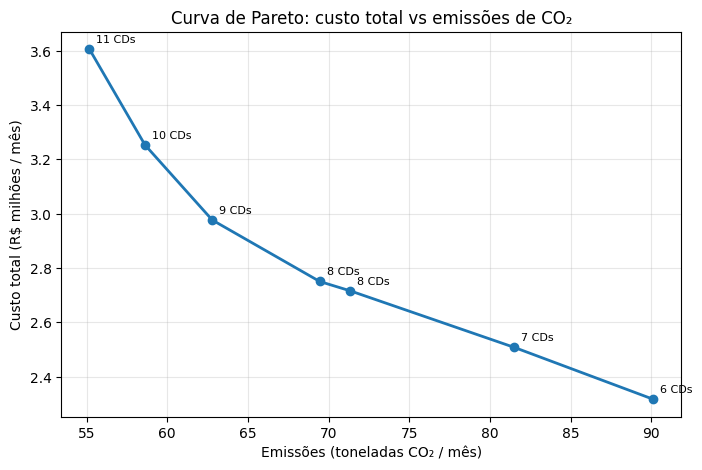

In [12]:
fig, ax = plt.subplots(figsize=(8,5))
df_ok = pareto.dropna()
ax.plot(df_ok["co2_efetivo"]/1000, df_ok["custo"]/1e6, "o-", lw=2)
ax.set_xlabel("Emissões (toneladas CO₂ / mês)")
ax.set_ylabel("Custo total (R$ milhões / mês)")
ax.set_title("Curva de Pareto: custo total vs emissões de CO₂")
for _, r in df_ok.iterrows():
    ax.annotate(f"{int(r['n_CDs'])} CDs", (r["co2_efetivo"]/1000, r["custo"]/1e6),
                xytext=(5,5), textcoords="offset points", fontsize=8)
ax.grid(alpha=.3); plt.show()

## 8. Conclusões

- O modelo **estendido** abre o **dobro de CDs** (10 vs 5) e tem custo total
  ~60% maior, mas reduz **CO₂ em ~29%** e cumpre o requisito de
  resiliência (≥ 2 fontes por cliente).
- O **transporte** cai 29% pois clientes são atendidos por CDs mais próximos —
  ganho ambiental e operacional.
- A curva de Pareto mostra que o custo marginal de redução adicional cresce
  rapidamente abaixo de ~70% das emissões do ótimo original.
- A formulação adicionou ~720 binárias (`z_ij`) e ~1500 restrições, mas o
  Gurobi resolve a instância em **menos de 0,1 s**.

---
*Projeto — Modelos e Algoritmos de Otimização (Prof. Sérgio Queiroz)*
*Cláudio Meireles · Felipe Dutra · Lucas Fiche · Pedro Araújo*